# TP 3: Logistic_Regression

**Group 1: I3-AMS-TPB**<br>

**Name: NUON CHANVATHANA**<br>

**ID: e20230118**

**Name: Ly LAISRUN**<br>

**ID: e20230616**

Remarks: All models here should be built from scratch.


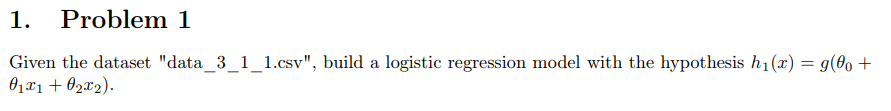

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data_3_1_1.csv')
df.head()

,x1,x2,class
0,6.70,6.79,1
1,6.92,3.87,1
2,7.87,5.36,1
3,2.93,6.91,0
4,6.67,4.92,1


In [4]:
X_train = df[['x1', 'x2']].sample(frac=0.8, random_state=42).values
X_test = df[['x1', 'x2']].drop(df.sample(frac=0.8, random_state=42).index).values
y_train = df['class'].sample(frac=0.8, random_state=42).values
y_test = df['class'].drop(df.sample(frac=0.8, random_state=42).index).values
m, n = X_train.shape
print(f"Number of training examples: {m}")

Number of training examples: 80


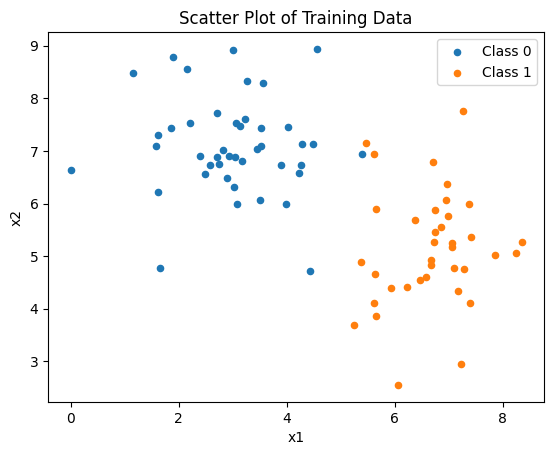

In [5]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

In [6]:
#sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#cost function
def cost_function(X, y, w, b):
    m = X.shape[0]
    cost_sum = 0
    epsilon = 1e-15

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        g = np.clip(g, epsilon, 1 - epsilon)

        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)

    return (1/m) * cost_sum

#gradient function
def gradient_function(X, y, w, b):
    m, n = X.shape
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        grad_b += (g - y[i])
        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i][j]


    grad_w = (1/m) * grad_w
    grad_b = (1/m) * grad_b
    return grad_w, grad_b

#gradient descent function
def gradient_descent(X, y, alpha, iterations):
    m,n = X.shape
    w = np.zeros(n)
    b = 0

    for it in range(iterations):
        grad_w, grad_b = gradient_function(X, y, w, b)

        w -= alpha * grad_w
        b -= alpha * grad_b

        if it % 100 == 0:
            cost = cost_function(X, y, w, b)
            print(f"Iteration {it}: Cost {cost_function(X, y, w, b)}")

    return w, b
                      

In [7]:
def predict(X, w, b):
    m = X.shape[0]
    preds = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        preds[i] = 1 if g >= 0.5 else 0

    return preds


In [8]:
def get_confusion_matrix(y_true, y_pred):
    # 1. Identify all unique classes and sort them for consistent indexing
    classes = sorted(list(set(y_true) | set(y_pred)))
    class_to_idx = {val: i for i, val in enumerate(classes)}
    size = len(classes)
    
    # 2. Initialize an empty (zeroed) square matrix
    matrix = [[0] * size for _ in range(size)]
    
    # 3. Fill the matrix by iterating through both lists simultaneously
    for actual, predicted in zip(y_true, y_pred):
        row = class_to_idx[actual]
        col = class_to_idx[predicted]
        matrix[row][col] += 1
        
    return matrix, classes

In [9]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, num_iterations)

predictions = predict(X_train, final_w, final_b)

accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6826646054751653
Iteration 100: Cost 0.2759924880250862
Iteration 200: Cost 0.18878848948646876
Iteration 300: Cost 0.15170856633036525
Iteration 400: Cost 0.13105931164809306
Iteration 500: Cost 0.11783098053288615
Iteration 600: Cost 0.10859825686357083
Iteration 700: Cost 0.1017705640795579
Iteration 800: Cost 0.09650666804070801
Iteration 900: Cost 0.09231886734612019
Iteration 1000: Cost 0.08890439897142438
Iteration 1100: Cost 0.08606507568373661
Iteration 1200: Cost 0.08366555699763552
Iteration 1300: Cost 0.0816101681343138
Iteration 1400: Cost 0.07982929909945036
Iteration 1500: Cost 0.07827105546427442
Iteration 1600: Cost 0.07689593415125585
Iteration 1700: Cost 0.07567331608537875
Iteration 1800: Cost 0.07457908992000285
Iteration 1900: Cost 0.07359400213468617
Iteration 2000: Cost 0.07270248647559838
Iteration 2100: Cost 0.0718918174145391
Iteration 2200: Cost 0.07115148736653142
Iteration 2300: Cost 0.07047274141660136
Iteration 2400: Cost 0.0698482248

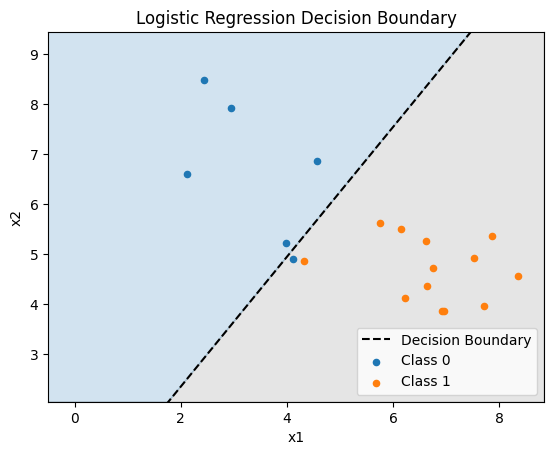

In [10]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:gray', alpha=0.2)
plt.fill_between(xd, yd, ymax,color='tab:blue', alpha=0.2)

plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

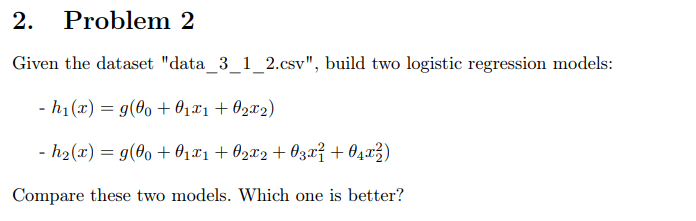

In [11]:
df_2 = pd.read_csv('data_3_1_2.csv')
df_2.head()

,x1,x2,class
0,9.076,3.721,0
1,6.809,3.930,0
2,8.256,2.851,1
3,8.461,3.145,1
4,6.783,3.188,1


In [12]:
df_2.shape

(200, 3)

In [13]:
X_train_1 = df_2[['x1', 'x2']].sample(frac=0.8, random_state=42).values
X_test_1 = df_2[['x1', 'x2']].drop(df_2.sample(frac=0.8, random_state=42).index).values
#this is correct because we use random_state=42 in both sampling and dropping to ensure the same split
y_train = df_2['class'].sample(frac=0.8, random_state=42).values
y_test = df_2['class'].drop(df_2.sample(frac=0.8, random_state=42).index).values
X_temp = df_2[['x1', 'x2']].copy()

X_temp['x1_squared'] = X_temp['x1'] ** 2
X_temp['x2_squared'] = X_temp['x2'] ** 2

X_train_2 = X_temp.sample(frac=0.8, random_state=42).values
X_test_2 = X_temp.drop(X_temp.sample(frac=0.8, random_state=42).index).values

m, n = X_train_1.shape
print("Shape of X_train_1:", X_train_1.shape)
print("Shape of X_train_2:", X_train_2.shape)
print(f"Number of training examples: {m}")

Shape of X_train_1: (160, 2)
Shape of X_train_2: (160, 4)
Number of training examples: 160


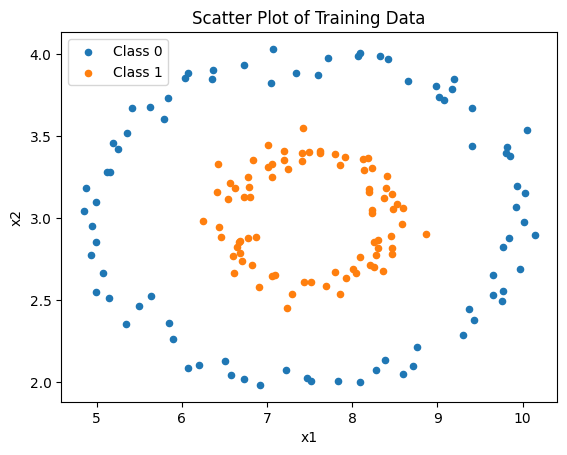

In [14]:
plt.scatter(X_train_1[y_train == 0, 0], X_train_1[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train_1[y_train == 1, 0], X_train_1[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

In [15]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(X_train_1, y_train, learning_rate, num_iterations)

predictions = predict(X_train_1, final_w, final_b)
predictions.shape
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6931470302667748
Iteration 100: Cost 0.6931346088811051
Iteration 200: Cost 0.6931249301799489
Iteration 300: Cost 0.6931173683780141
Iteration 400: Cost 0.6931114538583227
Iteration 500: Cost 0.6931068212378306
Iteration 600: Cost 0.6931031862328727
Iteration 700: Cost 0.6931003276583099
Iteration 800: Cost 0.6930980734217362
Iteration 900: Cost 0.6930962896263734
Iteration 1000: Cost 0.693094872092793
Iteration 1100: Cost 0.6930937397626127
Iteration 1200: Cost 0.6930928295664409
Iteration 1300: Cost 0.6930920924310171
Iteration 1400: Cost 0.6930914901726805
Iteration 1500: Cost 0.6930909930804013
Iteration 1600: Cost 0.6930905780353057
Iteration 1700: Cost 0.6930902270475929
Iteration 1800: Cost 0.6930899261182021
Iteration 1900: Cost 0.6930896643531316
Iteration 2000: Cost 0.6930894332743394
Iteration 2100: Cost 0.6930892262835813
Iteration 2200: Cost 0.6930890382452463
Iteration 2300: Cost 0.6930888651617764
Iteration 2400: Cost 0.69308870392112
Iteration 2500:

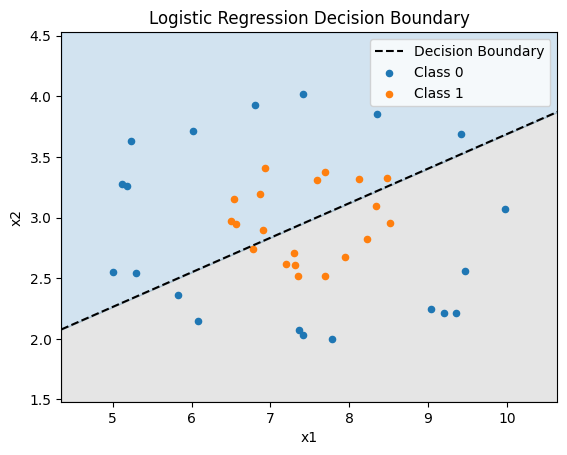

In [16]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin, xmax = X_train_1[:, 0].min() - 0.5, X_train_1[:, 0].max() + 0.5
ymin, ymax = X_train_1[:, 1].min() - 0.5, X_train_1[:, 1].max() + 0.5

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:gray', alpha=0.2)
plt.fill_between(xd, yd, ymax,color='tab:blue', alpha=0.2)

plt.scatter(X_test_1[y_test == 0, 0], X_test_1[y_test == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_test_1[y_test == 1, 0], X_test_1[y_test == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

In [17]:
get_confusion_matrix(y_train,predictions)

([[41, 39], [42, 38]], [np.int64(0), np.int64(1)])

In [18]:
learning_rate = 0.01
num_iterations = 10000
# Simple Z-score normalization
X_scaled = (X_train_2 - np.mean(X_train_2, axis=0)) / np.std(X_train_2, axis=0)
final_w, final_b = gradient_descent(X_scaled, y_train, learning_rate, num_iterations)
predictions = predict(X_scaled, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6931233390718421
Iteration 100: Cost 0.6912459013111883
Iteration 200: Cost 0.6899088546024128
Iteration 300: Cost 0.6887697877890578
Iteration 400: Cost 0.6877042570049292
Iteration 500: Cost 0.6866669572624695
Iteration 600: Cost 0.685641363391274
Iteration 700: Cost 0.6846214376306212
Iteration 800: Cost 0.6836049700296309
Iteration 900: Cost 0.6825911493216429
Iteration 1000: Cost 0.6815796756948479
Iteration 1100: Cost 0.6805704364472441
Iteration 1200: Cost 0.6795633873488406
Iteration 1300: Cost 0.6785585092318287
Iteration 1400: Cost 0.6775557921037715
Iteration 1500: Cost 0.6765552293330077
Iteration 1600: Cost 0.6755568155205669
Iteration 1700: Cost 0.6745605457214366
Iteration 1800: Cost 0.6735664151596978
Iteration 1900: Cost 0.6725744191244015
Iteration 2000: Cost 0.6715845529315573
Iteration 2100: Cost 0.6705968119102957
Iteration 2200: Cost 0.6696111913978626
Iteration 2300: Cost 0.6686276867378299
Iteration 2400: Cost 0.6676462932794786
Iteration 250

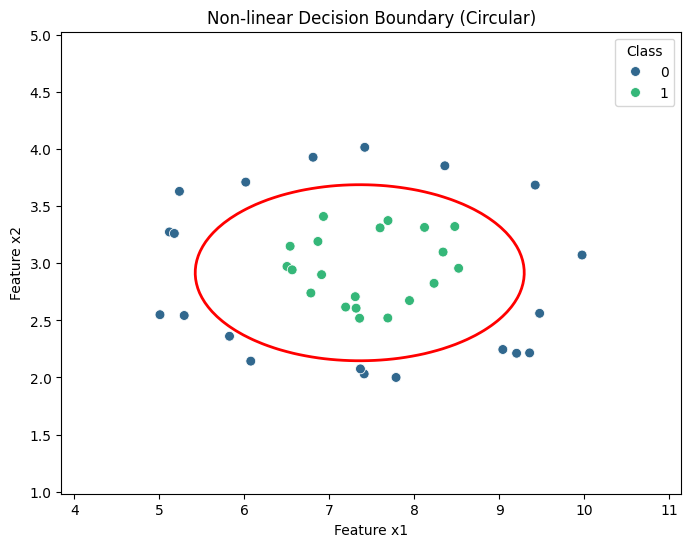

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Your weights and bias
weights = np.array([1.53313569, 1.48200905, -1.56888842, -1.53104136])
bias = -0.0001571431545626939

# 2. Get mean and std from your training data (CRITICAL for matching the scaling)
mu = np.mean(X_train_2, axis=0)
std = np.std(X_train_2, axis=0)

# 3. Create a grid of points over the range of your data
x_range = np.linspace(X_train_2[:, 0].min() - 1, X_train_2[:, 0].max() + 1, 100)
y_range = np.linspace(X_train_2[:, 1].min() - 1, X_train_2[:, 1].max() + 1, 100)
xx, yy = np.meshgrid(x_range, y_range)

# 4. Prepare the grid features to match your X_train_2 structure [x1, x2, x1^2, x2^2]
grid_points = np.c_[xx.ravel(), yy.ravel(), xx.ravel()**2, yy.ravel()**2]

# 5. Scale the grid points using the training mu and std
grid_points_scaled = (grid_points - mu) / std

# 6. Calculate Z (the linear part of the logistic regression: weights * X + bias)
# We plot the boundary where Z = 0
Z = grid_points_scaled @ weights + bias
Z = Z.reshape(xx.shape)

# 7. Plot using Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_2[:, 0], y=X_test_2[:, 1], hue=y_test, palette='viridis', s=50)
plt.contour(xx, yy, Z, levels=[0], colors='red', linewidths=2)

plt.title("Non-linear Decision Boundary (Circular)")
plt.xlabel("Feature x1")
plt.ylabel("Feature x2")
plt.legend(title='Class')
plt.show()

In [20]:
final_w,final_b

(array([ 1.52623082,  1.44467713, -1.58875164, -1.53170137]),
 np.float64(-0.0003815245207169876))

In [21]:
get_confusion_matrix(y_train,predictions)

([[74, 6], [0, 80]], [np.int64(0), np.int64(1)])

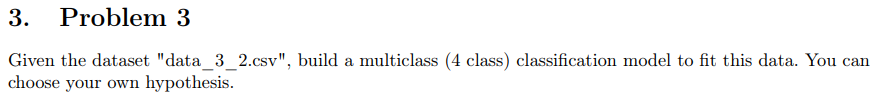

In [22]:
data = pd.read_csv('data_3_2.csv')
data.head()

,x1,x2,class
0,10.52,0.65,3
1,1.46,-1.25,2
2,1.50,0.56,2
3,-1.36,2.50,0
4,11.16,5.19,1


In [23]:
X = data[['x1', 'x2']].values
y = data['class'].values
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]
classes = np.unique(y)
num_classes = len(classes)
print(f"Unique classes: {classes}")

Unique classes: [0 1 2 3]


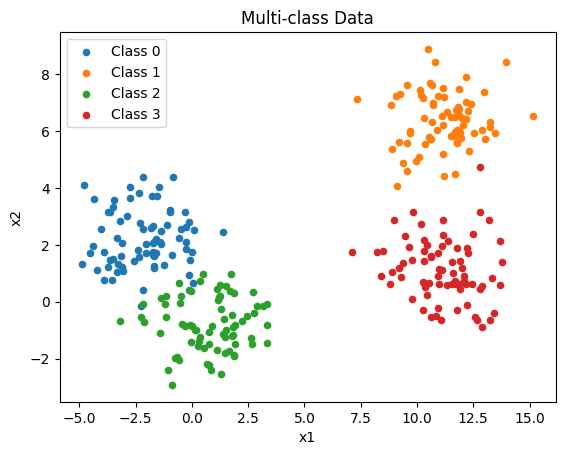

In [24]:
for c in classes:
    plt.scatter(X[y == c, 0], X[y == c, 1], label=f'Class {c}', s=20)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multi-class Data')
plt.legend()
plt.show()


In [25]:
weights = []
biases = []

for c in classes:
    print(f"Training classifier for class {c}")

    # Create binary labels
    y_binary = (y == c).astype(int)

    w, b = gradient_descent(X_train, y_binary[:80], alpha=0.1, iterations=1000)

    weights.append(w)
    biases.append(b)

weights = np.array(weights)
biases = np.array(biases)

Training classifier for class 0
Iteration 0: Cost 0.2783241631855548
Iteration 100: Cost 0.09976670799984019
Iteration 200: Cost 0.07243471906493712
Iteration 300: Cost 0.0580457280954136
Iteration 400: Cost 0.0489640938584355
Iteration 500: Cost 0.04265631308112958
Iteration 600: Cost 0.03798992078730316
Iteration 700: Cost 0.03437927956591574
Iteration 800: Cost 0.031490446397405746
Iteration 900: Cost 0.02911863091882156
Training classifier for class 1
Iteration 0: Cost 0.6703382892710695
Iteration 100: Cost 0.2546799346738368
Iteration 200: Cost 0.16551941114619712
Iteration 300: Cost 0.1256679115679712
Iteration 400: Cost 0.10266159930249463
Iteration 500: Cost 0.08749854764686368
Iteration 600: Cost 0.07666344039586168
Iteration 700: Cost 0.0684875428655509
Iteration 800: Cost 0.06207154156112658
Iteration 900: Cost 0.05688546331192876
Training classifier for class 2
Iteration 0: Cost 0.40639216113883814
Iteration 100: Cost 0.15210530749887852
Iteration 200: Cost 0.12054986434813

In [26]:
def predict_prob(X, w, b):
    m = X.shape[0]
    probs = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        probs[i] = sigmoid(z)

    return probs

In [27]:
#predict multiclass
def predict_multiclass(X, weights, biases):
    m = X.shape[0]
    num_classes = weights.shape[0]
    probs = np.zeros((m, num_classes))

    for c in range(num_classes):
        probs[:, c] = predict_prob(X, weights[c], biases[c])

    return np.argmax(probs, axis=1)

In [28]:
predictions = predict_multiclass(X_test, weights, biases)

accuracy = np.mean(predictions == y_test) * 100
print(f"\nMulticlass Accuracy: {accuracy:.2f}%")


Multiclass Accuracy: 96.82%


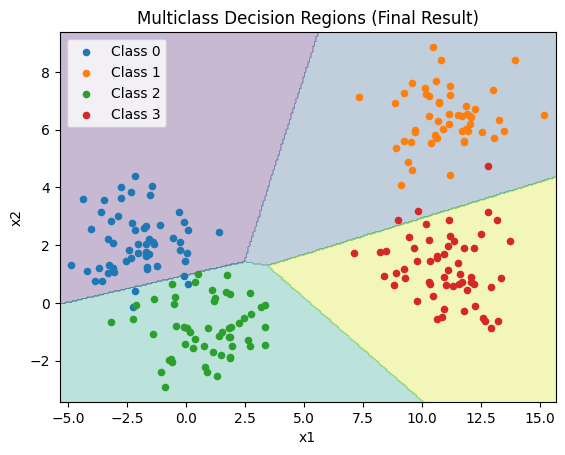

In [29]:
# Plot decision regions 
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grid = np.c_[xx1.ravel(), xx2.ravel()]

# Predict class for each grid point
Z = predict_multiclass(grid, weights, biases)
Z = Z.reshape(xx1.shape)

# Plot decision regions
plt.contourf(xx1, xx2, Z, alpha=0.3)

# Plot actual data points
for c in classes:
    plt.scatter(X_test[y_test == c, 0], X_test[y_test == c, 1], label=f'Class {c}', s=20)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multiclass Decision Regions (Final Result)')
plt.legend()
plt.show()

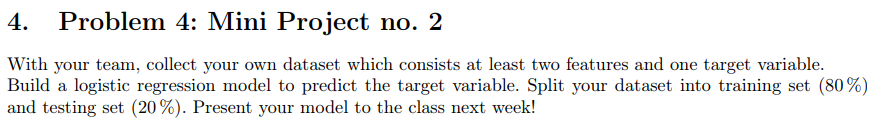

## we do a survey about people preference study mode in person vs online  

In [30]:
df = pd.read_csv('Learning Mode Preference (Responses) - Form Responses 1.csv')

In [31]:
df = df.drop(columns=['Timestamp'])

In [32]:
col = ['study_mode','friend','solo_study','teacher_factor','introvert_level']
df.columns = col

In [33]:
df['study_mode'] = df['study_mode'].map({'IN-PERSON': 0, 'ONLINE': 1})

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   study_mode       24 non-null     int64
 1   friend           24 non-null     int64
 2   solo_study       24 non-null     int64
 3   teacher_factor   24 non-null     int64
 4   introvert_level  24 non-null     int64
dtypes: int64(5)
memory usage: 1.1 KB


In [35]:
df.describe()

,study_mode,friend,solo_study,teacher_factor,introvert_level
count,24.000000,24.000000,24.000000,24.000000,24.000000
mean,0.291667,29.625000,7.458333,8.041667,6.208333
std,0.464306,112.050382,1.641292,1.428869,2.166527
min,0.000000,0.000000,4.000000,5.000000,2.000000
25%,0.000000,3.000000,6.750000,7.000000,5.000000
50%,0.000000,5.000000,7.000000,8.000000,6.000000
75%,1.000000,10.500000,9.000000,9.000000,8.000000
max,1.000000,555.000000,10.000000,10.000000,10.000000


In [36]:
x_train = df[['friend','solo_study','teacher_factor','introvert_level']].sample(frac = 0.8, random_state=42).values
y_train = df['study_mode'].sample(frac = 0.8, random_state=42).values
x_test = df[['friend','solo_study','teacher_factor','introvert_level']].drop(df.sample(frac = 0.8, random_state=42).index).values
y_test = df['study_mode'].drop(df.sample(frac = 0.8, random_state=42).index).values
# the random state is the same so we don't need to worry about our data split being inconsistent between features and labels


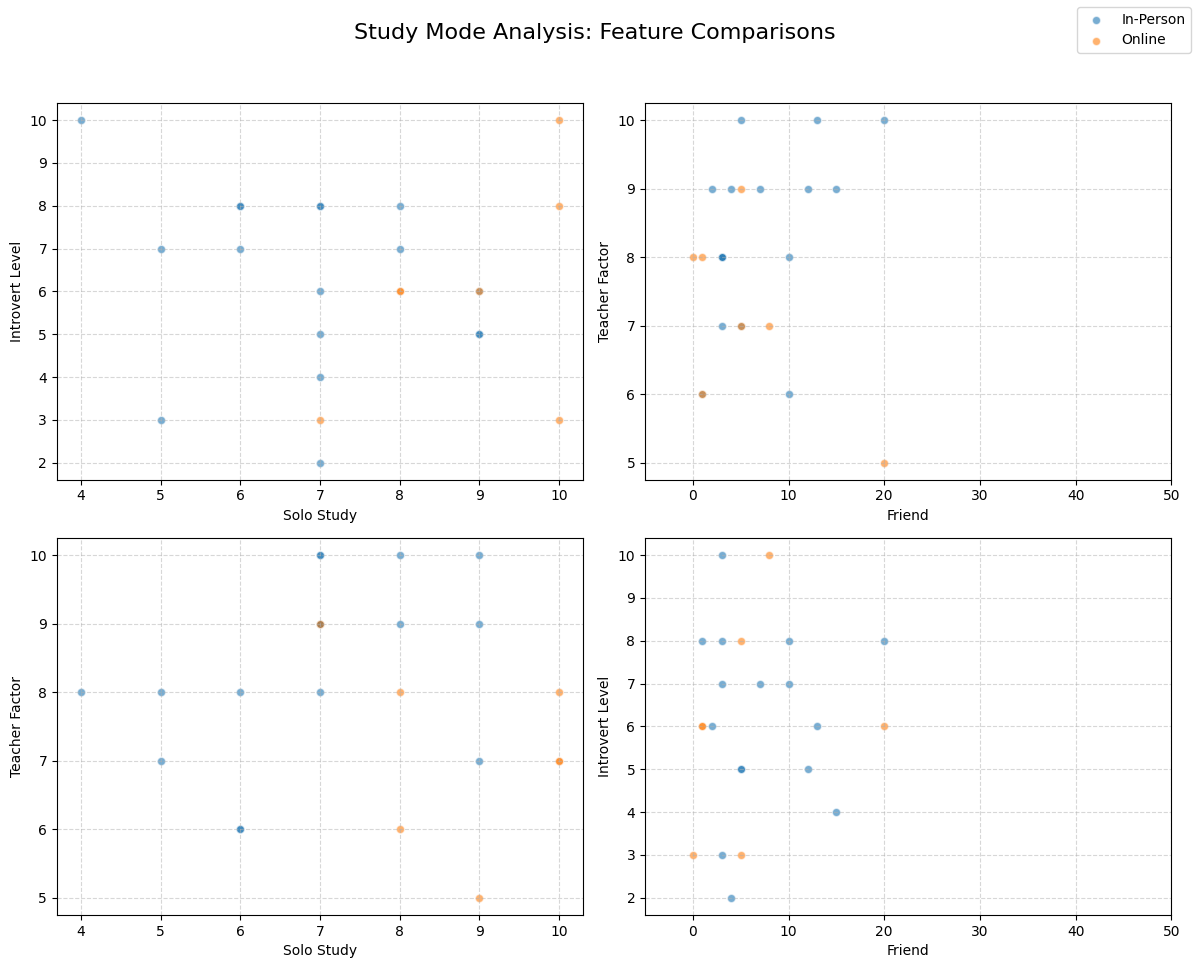

In [37]:
import matplotlib.pyplot as plt

# Setup the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Study Mode Analysis: Feature Comparisons', fontsize=16)

# Define our feature pairs for the 4 plots
pairs = [
    ('solo_study', 'introvert_level'),
    ('friend', 'teacher_factor'),
    ('solo_study', 'teacher_factor'),
    ('friend', 'introvert_level')
]

# Loop through the axes and pairs to plot
for i, ax in enumerate(axes.flat):
    x_feat, y_feat = pairs[i]
    
    # Plot Class 0 (In-Person)
    ax.scatter(df[df['study_mode'] == 0][x_feat], 
               df[df['study_mode'] == 0][y_feat], 
               c='tab:blue', label='In-Person', alpha=0.6, edgecolors='w')
    
    # Plot Class 1 (Online)
    ax.scatter(df[df['study_mode'] == 1][x_feat], 
               df[df['study_mode'] == 1][y_feat], 
               c='tab:orange', label='Online', alpha=0.6, edgecolors='w')
    
    ax.set_xlabel(x_feat.replace('_', ' ').title())
    ax.set_ylabel(y_feat.replace('_', ' ').title())
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Handle the 'friend' outlier so the plot is readable
    if x_feat == 'friend':
        ax.set_xlim(-5, 50) # Clipping the X-axis to focus on the bulk of data
    if y_feat == 'friend':
        ax.set_ylim(-5, 50)

# Add a single legend for the whole figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [38]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(x_train, y_train, learning_rate, num_iterations)

Iteration 0: Cost 0.5505660972735275
Iteration 100: Cost 0.4501407855117542
Iteration 200: Cost 0.41712738497642715
Iteration 300: Cost 0.3990239403089225
Iteration 400: Cost 0.38822779383062933
Iteration 500: Cost 0.3814057012021177
Iteration 600: Cost 0.37689980849569954
Iteration 700: Cost 0.3738209874928017
Iteration 800: Cost 0.37166139765207795
Iteration 900: Cost 0.37011518746385064
Iteration 1000: Cost 0.36898992140035664
Iteration 1100: Cost 0.36816011658601966
Iteration 1200: Cost 0.3675415211514667
Iteration 1300: Cost 0.3670761900036379
Iteration 1400: Cost 0.3667234684066892
Iteration 1500: Cost 0.36645435322157843
Iteration 1600: Cost 0.3662478607364633
Iteration 1700: Cost 0.3660886269722393
Iteration 1800: Cost 0.3659652872509763
Iteration 1900: Cost 0.3658693610800276
Iteration 2000: Cost 0.36579447203652204
Iteration 2100: Cost 0.3657357941004517
Iteration 2200: Cost 0.36568965370821377
Iteration 2300: Cost 0.36565324052996
Iteration 2400: Cost 0.36562439519078666
Ite

In [39]:
predictions = predict(x_train, final_w, final_b)
predictions.shape
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Training Accuracy: 84.21%


In [40]:
get_confusion_matrix(y_train, predictions)

([[12, 1], [2, 4]], [np.int64(0), np.int64(1)])

In [41]:
predictions = predict(x_test, final_w, final_b)
predictions.shape
accuracy = np.mean(predictions == y_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 80.00%


In [42]:
get_confusion_matrix(y_test, predictions)

([[4, 0], [1, 0]], [np.int64(0), np.int64(1)])

Text(0.5, 1.0, 'Distribution of Study Mode Preferences')

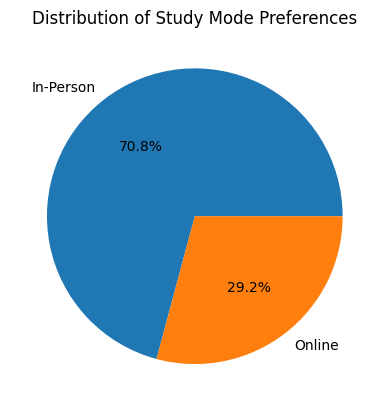

In [43]:
plt.pie(df['study_mode'].value_counts(), labels=['In-Person', 'Online'], autopct='%1.1f%%', colors=['tab:blue', 'tab:orange'])
plt.title('Distribution of Study Mode Preferences')

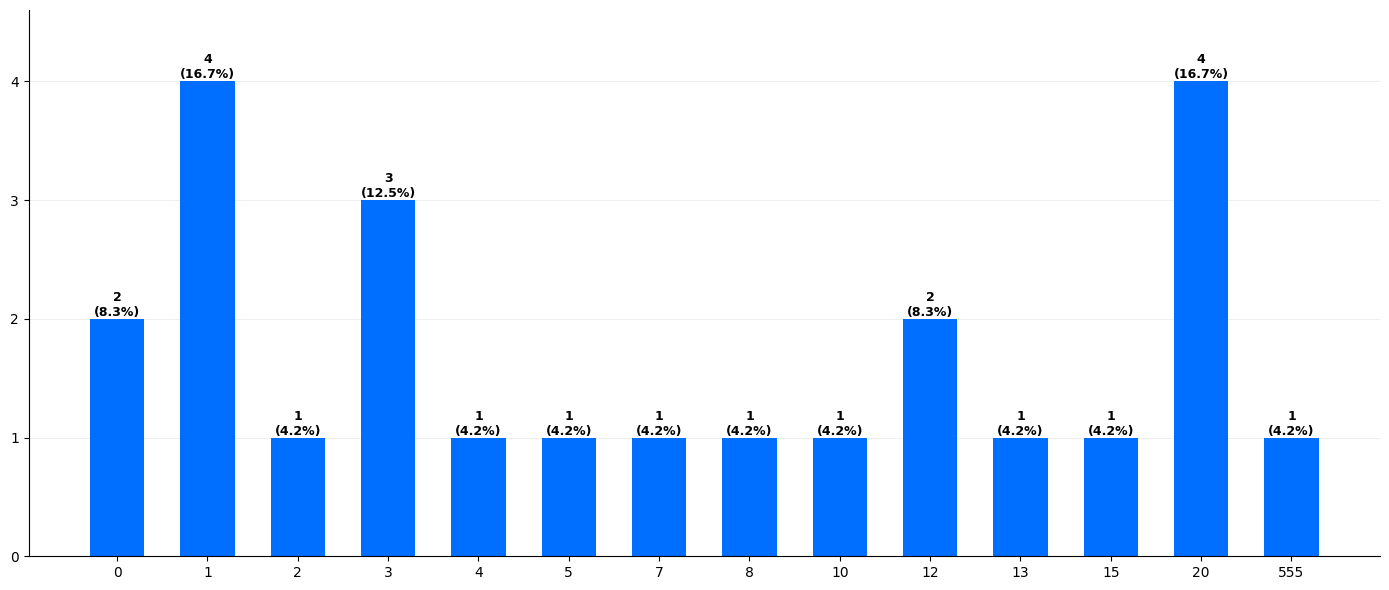

In [56]:
# Sample data
categories = df['friend'].unique()  # Assuming 'friend' is the feature you want to plot
values = df['friend'].value_counts()
percentages = (values / values.sum() * 100).round(1)

# Sort by category (already sorted in this case, but here's how to do it explicitly)
sorted_data = sorted(zip(categories, values, percentages), key=lambda x: x[0])
categories, values, percentages = zip(*sorted_data)

fig, ax = plt.subplots(figsize=(14, 6))

# Create bars
bars = ax.bar(range(len(categories)), values, color="#006EFF", width=0.6)

# Add value and percentage labels on top of bars
for i, (bar, val, pct) in enumerate(zip(bars, values, percentages)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val)}\n({pct}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize the chart
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories)
ax.set_ylim(0, max(values) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
def random_oversample(X_minority, n_samples, noise_scale=0.05):
    synthetic = []
    for _ in range(n_samples):
        # Pick a random minority sample
        idx = np.random.randint(0, len(X_minority))
        sample = X_minority[idx].copy()
        
        # Add tiny noise so it's not an exact duplicate
        noise = np.random.normal(0, noise_scale, sample.shape)
        synthetic.append(sample + noise)
    
    return np.array(synthetic)

# Split by class
X_minority = x_train[y_train == 1]
X_majority = x_train[y_train == 0]

print(f"Before — In-Person: {len(X_majority)}, Online: {len(X_minority)}")

n_to_generate = len(X_majority) - len(X_minority)
synthetic_samples = random_oversample(X_minority, n_to_generate, noise_scale=0.05)

# Combine
x_train_bal = np.vstack([x_train, synthetic_samples])
y_train_bal = np.hstack([y_train, np.ones(n_to_generate)])
x_test_bal = np.vstack([x_test, synthetic_samples])
y_test_bal = np.hstack([y_test, np.ones(n_to_generate)])
print(f"After  — In-Person: {len(X_majority)}, Online: {len(X_minority) + n_to_generate}")

# Retrain
final_w, final_b = gradient_descent(x_train_bal, y_train_bal, 0.01,10000)

predictions = predict(x_test_bal, final_w, final_b)
accuracy = np.mean(predictions == y_test_bal) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Before — In-Person: 13, Online: 6
After  — In-Person: 13, Online: 13
Iteration 0: Cost 0.6486898698655589
Iteration 100: Cost 0.5018424003795843
Iteration 200: Cost 0.47202411111604015
Iteration 300: Cost 0.45634573072926393
Iteration 400: Cost 0.4471931393503873
Iteration 500: Cost 0.44143528834964213
Iteration 600: Cost 0.43761047856692253
Iteration 700: Cost 0.43496639663180114
Iteration 800: Cost 0.4330831506763182
Iteration 900: Cost 0.4317106941457966
Iteration 1000: Cost 0.4306922863590842
Iteration 1100: Cost 0.42992557938397086
Iteration 1200: Cost 0.4293415065077273
Iteration 1300: Cost 0.4288921902687663
Iteration 1400: Cost 0.4285436955892066
Iteration 1500: Cost 0.4282715180155215
Iteration 1600: Cost 0.42805768259010246
Iteration 1700: Cost 0.42788882614217505
Iteration 1800: Cost 0.4277548990928747
Iteration 1900: Cost 0.42764826827837915
Iteration 2000: Cost 0.4275630856063788
Iteration 2100: Cost 0.42749483666582777
Iteration 2200: Cost 0.4274400134382988
Iteration 230

In [ ]:
cm, classes = get_confusion_matrix(y_test, predictions)

TN = int(cm[0][0])
FP = int(cm[0][1])
FN = int(cm[1][0])
TP = int(cm[1][1])

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy  = (TP + TN) / (TP + TN + FP + FN)

# AUC approximation using predicted probabilities
probs = np.array([sigmoid(np.dot(final_w, x) + final_b) for x in x_test])

def compute_auc(y_true, y_probs):
    thresholds = np.linspace(0, 1, 100)
    tprs, fprs = [], []
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        tp = np.sum((preds == 1) & (y_true == 1))
        fp = np.sum((preds == 1) & (y_true == 0))
        fn = np.sum((preds == 0) & (y_true == 1))
        tn = np.sum((preds == 0) & (y_true == 0))
        tprs.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    # AUC via trapezoidal rule
    fprs, tprs = zip(*sorted(zip(fprs, tprs)))
    auc = np.trapz(tprs, fprs)
    return auc

auc = compute_auc(y_test, probs)

# Print as a neat table
print(f"{'Classifier':<12} {'AUC':<8} {'F1 (%)':<10} {'Precision (%)':<16} {'Recall (%)':<12} {'Accuracy (%)'}")
print("-" * 70)
print(f"{'LR':<12} {auc:<8.3f} {f1*100:<10.0f} {precision*100:<16.0f} {recall*100:<12.0f} {accuracy*100:.0f}")

Classifier   AUC      F1 (%)     Precision (%)    Recall (%)   Accuracy (%)
----------------------------------------------------------------------
LR           1.000    100        100              100          100


C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_20704\2218346067.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tprs, fprs)


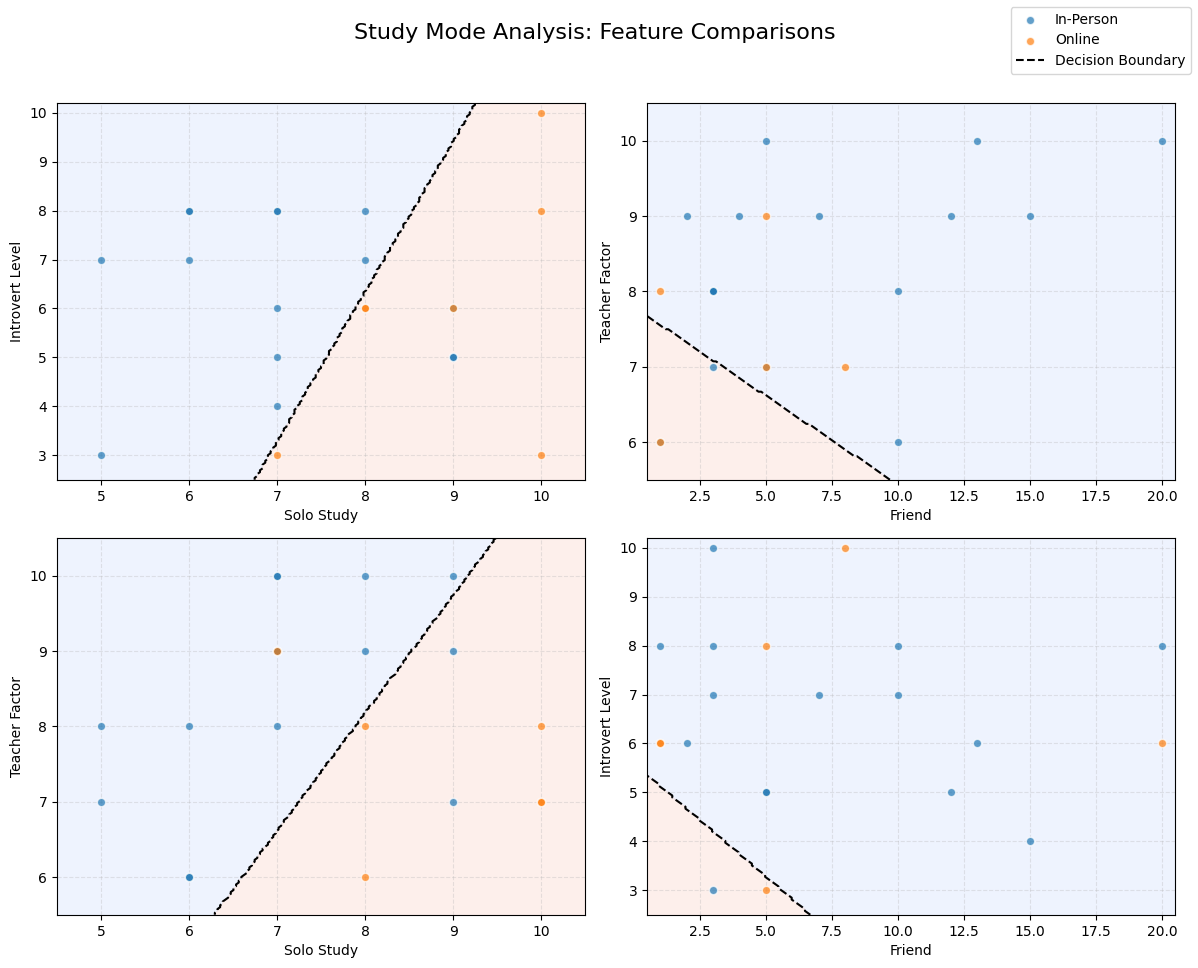

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Study Mode Analysis: Feature Comparisons', fontsize=16)

feature_names = ['friend', 'solo_study', 'teacher_factor', 'introvert_level']
feature_means = df[feature_names].median()  # median instead of mean, safer with outliers

pairs = [
    ('solo_study', 'introvert_level'),
    ('friend', 'teacher_factor'),
    ('solo_study', 'teacher_factor'),
    ('friend', 'introvert_level')
]

for i, ax in enumerate(axes.flat):
    x_feat, y_feat = pairs[i]
    xi = feature_names.index(x_feat)
    yi = feature_names.index(y_feat)

    # Use quantile-based limits to handle extreme values — no data removed!
    x_lim = (df[x_feat].quantile(0.05) - 0.5, df[x_feat].quantile(0.95) + 0.5)
    y_lim = (df[y_feat].quantile(0.05) - 0.5, df[y_feat].quantile(0.95) + 0.5)

    # Build a 2D grid within the visible range
    xx, yy = np.meshgrid(np.linspace(x_lim[0], x_lim[1], 200),
                         np.linspace(y_lim[0], y_lim[1], 200))

    # Fill in the other 2 features with their median
    grid_4d = np.zeros((xx.ravel().shape[0], 4))
    for j, fname in enumerate(feature_names):
        if j == xi:
            grid_4d[:, j] = xx.ravel()
        elif j == yi:
            grid_4d[:, j] = yy.ravel()
        else:
            grid_4d[:, j] = feature_means[fname]

    # Predict on the grid
    Z = predict(grid_4d, final_w, final_b).reshape(xx.shape)

    # Shaded regions
    ax.contourf(xx, yy, Z, alpha=0.15, cmap='coolwarm', levels=[-0.5, 0.5, 1.5])
    # Decision boundary line
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=1.5)

    # Scatter points
    ax.scatter(df[df['study_mode'] == 0][x_feat],
               df[df['study_mode'] == 0][y_feat],
               c='tab:blue', label='In-Person', alpha=0.7, edgecolors='w', zorder=3)
    ax.scatter(df[df['study_mode'] == 1][x_feat],
               df[df['study_mode'] == 1][y_feat],
               c='tab:orange', label='Online', alpha=0.7, edgecolors='w', zorder=3)

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_xlabel(x_feat.replace('_', ' ').title())
    ax.set_ylabel(y_feat.replace('_', ' ').title())
    ax.grid(True, linestyle='--', alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
# Add decision boundary to legend manually
from matplotlib.lines import Line2D
handles += [Line2D([0], [0], color='black', linestyle='--', linewidth=1.5)]
labels += ['Decision Boundary']

fig.legend(handles, labels, loc='upper right')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
def k_fold_cv(X, y, k=5, learning_rate=0.01, iterations=10000):
    n = len(X)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)
    
    accuracies = []
    
    for i in range(k):
        # Test fold = fold i, Train fold = everything else
        test_idx  = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx],  y[test_idx]
        
        # Oversample on train fold only
        X_min = X_tr[y_tr == 1]
        X_maj = X_tr[y_tr == 0]
        n_gen = len(X_maj) - len(X_min)
        
        if n_gen > 0 and len(X_min) > 0:
            synthetic = random_oversample(X_min, n_gen)
            X_tr = np.vstack([X_tr, synthetic])
            y_tr = np.hstack([y_tr, np.ones(n_gen)])
        
        w, b = gradient_descent(X_tr, y_tr, learning_rate, iterations)
        preds = predict(X_te, w, b)
        acc = np.mean(preds == y_te) * 100
        accuracies.append(acc)
        print(f"Fold {i+1}: {acc:.1f}%")
    
    print(f"\nMean Accuracy: {np.mean(accuracies):.1f}%")
    print(f"Std:           {np.std(accuracies):.1f}%")
    return accuracies

X_all = df[['friend','solo_study','teacher_factor','introvert_level']].values
y_all = df['study_mode'].values
k_fold_cv(X_all, y_all, k=5)

Iteration 0: Cost 0.6119532290159649
Iteration 100: Cost 0.3904123269973619
Iteration 200: Cost 0.3394767760164612
Iteration 300: Cost 0.30997651425048645
Iteration 400: Cost 0.2904652966319368
Iteration 500: Cost 0.27661793970598075
Iteration 600: Cost 0.2663025778989265
Iteration 700: Cost 0.25833160182719567
Iteration 800: Cost 0.25199038275597324
Iteration 900: Cost 0.24682423561859163
Iteration 1000: Cost 0.24253103175137192
Iteration 1100: Cost 0.23890280082456294
Iteration 1200: Cost 0.23579209575447174
Iteration 1300: Cost 0.23309171055845765
Iteration 1400: Cost 0.23072197657541488
Iteration 1500: Cost 0.22862254464715015
Iteration 1600: Cost 0.2267469189258076
Iteration 1700: Cost 0.22505873108768665
Iteration 1800: Cost 0.22352914532718138
Iteration 1900: Cost 0.2221350157269256
Iteration 2000: Cost 0.22085755497959447
Iteration 2100: Cost 0.2196813573573968
Iteration 2200: Cost 0.21859367137613636
Iteration 2300: Cost 0.21758385125076288
Iteration 2400: Cost 0.2166429382272

[np.float64(60.0),
 np.float64(80.0),
 np.float64(100.0),
 np.float64(100.0),
 np.float64(50.0)]

Iteration 0: Cost 0.99903610851914
Iteration 100: Cost 0.4497210994231919
Iteration 200: Cost 0.38449472030058957
Iteration 300: Cost 0.35220653483607545
Iteration 400: Cost 0.33382872979302575
Iteration 500: Cost 0.322359000212
Iteration 600: Cost 0.3147262679729424
Iteration 700: Cost 0.30940428756619925
Iteration 800: Cost 0.30556085757623136
Iteration 900: Cost 0.30270869922997345
Iteration 1000: Cost 0.3005460168314239
Iteration 1100: Cost 0.29887726889280736
Iteration 1200: Cost 0.29757100733511294
Iteration 1300: Cost 0.2965361354153637
Iteration 1400: Cost 0.29570788803189957
Iteration 1500: Cost 0.2950392132795929
Iteration 1600: Cost 0.29449528880801323
Iteration 1700: Cost 0.2940499275406509
Iteration 1800: Cost 0.2936831601031658
Iteration 1900: Cost 0.2933795714744156
Iteration 2000: Cost 0.2931271334600333
Iteration 2100: Cost 0.29291637051908237
Iteration 2200: Cost 0.29273975424592463
Iteration 2300: Cost 0.2925912575351426
Iteration 2400: Cost 0.2924660220825389
Iterat

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_20704\1334519533.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Iteration 3700: Cost 0.08017630144750033
Iteration 3800: Cost 0.0789119160750326
Iteration 3900: Cost 0.07769163649116645
Iteration 4000: Cost 0.07651313664388627
Iteration 4100: Cost 0.07537425435520208
Iteration 4200: Cost 0.07427297666107305
Iteration 4300: Cost 0.07320742677804873
Iteration 4400: Cost 0.07217585247642662
Iteration 4500: Cost 0.0711766156753147
Iteration 4600: Cost 0.07020818310390445
Iteration 4700: Cost 0.06926911789691015
Iteration 4800: Cost 0.06835807201159415
Iteration 4900: Cost 0.06747377936991888
Iteration 5000: Cost 0.06661504964280004
Iteration 5100: Cost 0.06578076260467818
Iteration 5200: Cost 0.06496986299610474
Iteration 5300: Cost 0.06418135584005291
Iteration 5400: Cost 0.0634143021644799
Iteration 5500: Cost 0.06266781508949128
Iteration 5600: Cost 0.061941056242451255
Iteration 5700: Cost 0.061233232468681426
Iteration 5800: Cost 0.06054359280910903
Iteration 5900: Cost 0.059871425719450984
Iteration 6000: Cost 0.059216056508320576
Iteration 6100:

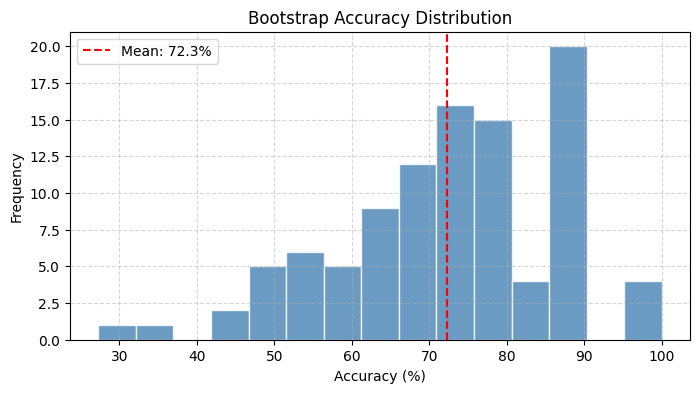

[np.float64(66.66666666666666),
 np.float64(71.42857142857143),
 np.float64(66.66666666666666),
 np.float64(88.88888888888889),
 np.float64(80.0),
 np.float64(66.66666666666666),
 np.float64(77.77777777777779),
 np.float64(50.0),
 np.float64(80.0),
 np.float64(85.71428571428571),
 np.float64(57.14285714285714),
 np.float64(85.71428571428571),
 np.float64(75.0),
 np.float64(54.54545454545454),
 np.float64(75.0),
 np.float64(66.66666666666666),
 np.float64(87.5),
 np.float64(42.857142857142854),
 np.float64(62.5),
 np.float64(63.63636363636363),
 np.float64(85.71428571428571),
 np.float64(100.0),
 np.float64(53.84615384615385),
 np.float64(80.0),
 np.float64(62.5),
 np.float64(80.0),
 np.float64(66.66666666666666),
 np.float64(71.42857142857143),
 np.float64(77.77777777777779),
 np.float64(76.92307692307693),
 np.float64(27.27272727272727),
 np.float64(85.71428571428571),
 np.float64(50.0),
 np.float64(62.5),
 np.float64(77.77777777777779),
 np.float64(66.66666666666666),
 np.float64(90.

In [ ]:
def bootstrap_cv(X, y, n_iterations=100, learning_rate=0.01, iterations=10000):
    n = len(X)
    accuracies = []
    
    for i in range(n_iterations):
        # Draw n samples with replacement
        train_idx = np.random.choice(n, size=n, replace=True)
        # Test set = samples that were never drawn (~37% of data)
        test_idx  = np.array(list(set(range(n)) - set(train_idx)))
        
        if len(test_idx) == 0:
            continue  # skip if all samples were drawn (rare but possible)
        
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx],  y[test_idx]
        
        # Oversample minority on train only
        X_min = X_tr[y_tr == 1]
        X_maj = X_tr[y_tr == 0]
        n_gen = len(X_maj) - len(X_min)
        
        if n_gen > 0 and len(X_min) > 0:
            synthetic = random_oversample(X_min, n_gen)
            X_tr = np.vstack([X_tr, synthetic])
            y_tr = np.hstack([y_tr, np.ones(n_gen)])
        
        w, b = gradient_descent(X_tr, y_tr, learning_rate, iterations)
        preds = predict(X_te, w, b)
        acc = np.mean(preds == y_te) * 100
        accuracies.append(acc)
    
    print(f"Bootstrap Results over {n_iterations} iterations:")
    print(f"Mean Accuracy: {np.mean(accuracies):.1f}%")
    print(f"Std:           {np.std(accuracies):.1f}%")
    print(f"Min:           {np.min(accuracies):.1f}%")
    print(f"Max:           {np.max(accuracies):.1f}%")
    
    # Plot distribution of accuracies
    plt.figure(figsize=(8, 4))
    plt.hist(accuracies, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
    plt.axvline(np.mean(accuracies), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(accuracies):.1f}%')
    plt.xlabel('Accuracy (%)')
    plt.ylabel('Frequency')
    plt.title('Bootstrap Accuracy Distribution')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
    return accuracies

X_all = df[['friend','solo_study','teacher_factor','introvert_level']].values
y_all = df['study_mode'].values
bootstrap_cv(X_all, y_all, n_iterations=100)